# **Trabalho Prático:** - Aprendizagem Computacional I (CC2008) 25/26
## **Elementos do Grupo (PL4 - G6)**: Aly Mohamed (202401045), Amanda Carneiro (202400455) e Kirill Egorkin (202400361)

---

# 0) Introdução:  
&nbsp; O objetivo deste projeto prático é entender, na **teoria e prática**, como um determinado algoritmo de **Machine Learning** funciona, como é realizado sua avaliação comparativa **(benchmarketing)**, e perceber a **diferença** entre estudo e **pesquisa** de tal algoritmo da sua **aplicação** efetiva em um problema específico.  

---


# 1) Primeira Fase:  

## 1.1) Selecionar, Estudar e Implementar:  
&nbsp; O escopo do projeto tem como alvo algoritmos de Machine Learning que utilizam **Aprendizado Supervisionado** (Supervised Learning). Ou seja, a tarefa de aprendizagem é a **previsão**, nesse tipo de algoritmo o objetivo consiste em encontrar uma função (modelo ou hipótese), a partir dos dados de treino que possa ser utilizada para prever um rótulo ou valor que caracterize um novo exemplo. De acordo com o livro "Extração de Conhecimento de Dados - Data Mining", que é utilizado como referência nesta cadeira, podemos definir:

> " O termo supervisionada vem da simulação da presença de um supervisor externo, que conhece a saída (rótulo) associada a cada exemplo (conjunto de valores para os atributos de entrada). Com base neste conhecimento, o supervisor externo pode avaliar a capacidade da hipótese induzida em predizer o valor de saída para novos exemplos."  

&nbsp;O **Aprendizado Supervisionado** pode ser dividido em dois principais compos: **Classificação e Regressão**. A principal diferença destes dois se encontra no tipo de dados a serem utilizados, a Classificação prevê uma **categoria** (rótulo), enquanto a Regressão prevê um **valor** contínuo. De acordo com o livro supracitado:  

>"Uma definição formal é: dado um conjunto de observações de pares $D = {(xi, f(xi)),i =1,...,n}$, em que $f$ representa uma função desconhecida, um algoritmo de ECD preditivo aprende uma aproximação $\hat{f}$ da função desconhecida $f$ . Essa função aproximada, $\hat{f}$ , permite estimar o valor de $f$ para novas observações de $x$. De acordo com a natureza de f ,é comum distinguir duas situações possíveis:  
> * **Classificação:** $y_i = \hat{f}(\mathbf{x}_i) \in \{c_1, \dots, c_m\}$, ou seja, $\hat{f}(\mathbf{x}_i)$ assume valores num conjunto discreto, não ordenado;
> * **Regressão:** $y_i = \hat{f}(\mathbf{x}_i) \in \mathbb{R}$, ou seja, $\hat{f}(\mathbf{x}_i)$ assume valores num conjunto infinito e ordenado."  

<div align="center">
    <img src="img/Screenshot 2026-05-18 220321.png" width="800px"><br>
    <small>Figura 1: Imagem retirado do livro  "Extração de Conhecimento de Dados - Data Mining" (pg. 72).</small>

</div>

&nbsp;Existem diversos algoritmos clássicos que servem para as funções citadas a cima, para este projeto, optamos por explorar e analisar o algoritmo de classificação **Regressão Logística** (Logistic Regression).  



#### 1.1.1) Regressão Logística - A teoria matemática
&nbsp;O algoritmo **Regressão Logística**, embora contenha 'Regressão' em seu nome, é um algoritmo **probabilístico de classificação discriminativo**. Em termos matemáticos, em vez de prever o rótulo $Y$ diretamente a partir das características $X$, ele calcula a probabilidade condicional: $$P(Y = \text{classe} \mid X)$$ &nbsp;Isso significa "A probabilidade de ser a classe Y, dado que temos as características X". Como se era esperado, esses algoritmos utilizam da lógica Bayesiana, de probabilidade condicionada:$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$ 
* $P(A \mid B)$ [Posterior]: A probabilidade de o evento $A$ acontecer, dado que o evento $B$ já aconteceu. É o que queremos descobrir (ex: a probabilidade de o paciente ter uma doença, dado que o teste deu positivo).
* $P(B \mid A)$ [Verossimilhança / Likelihood]: A probabilidade de o evento $B$ acontecer, dado que o evento $A$ é verdadeiro (ex: qual a probabilidade de o teste dar positivo em alguém que sabidamente tem a doença?).
* $P(A)$ [Prior]: A probabilidade básica de $A$ acontecer antes de qualquer nova evidência. É o nosso conhecimento prévio do mundo (ex: a taxa geral da doença na população).
* $P(B)$ [Evidência]: A probabilidade total de o evento $B$ acontecer, sob qualquer circunstância (ex: a probabilidade geral de o teste dar positivo, seja a pessoa doente ou saudável).  



&nbsp;Como **Regressão Logística** é um algoritmo de **Classificação**, ele precisa garantir que essa probabilidade, seja discretizada para um rótulo, como 0 ou 1, 'Sim" ou 'Não" e etc. Para isso o algoritmo pega a equação da reta tradicional (função discriminante linear): $$z = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_nX_n$$ E aplica essa equação dentro de uma função matemática chamada **Função Sigmóide** (ou Função Logística): $$g(z) = \frac{1}{1 + e^{-z}}$$ Dessa forma, não importa o quão grande ou pequeno seja o valor de $z$, a **Função Sigmóide** vai espremê-lo para dentro do intervalo entre $0$ e $1$.O gráfico dessa função tem o formato de um "S":    


<div align="center">
<img src="img/Screenshot 2026-05-18 223451.png" width="1000px"><br>


<small>Figura 2 : Gráfico gerado pela equipa através da ferramenta Desmos.</small>
</div>  

&nbsp;Após essa discretização, é preciso decidir o **Limiar de Decisão**. Uma vez que o modelo calcula a probabilidade, para tomar a decisão final da classificação, é necessário definir um limiar de decisão (Decision Threshold), esse limiar varia, como suposto, entre 0 e 1, vejamos o exemplo onde esse limiar é representado por 0.5 (mais comum):  

<div align="center">
<img src="img/Screenshot 2026-05-18 224247.png" width="1000px"><br>
<small>Figura 3 : Gráfico gerado pela equipa através da ferramenta Desmos.</small>
</div>

Dessa forma, qualquer previsão:
* Se a probabilidade calculada for $\ge 0.5$, o modelo classifica como 1 (Ex: É Spam).
* Se a probabilidade calculada for $< 0.5$, o modelo classifica como 0 (Ex: Não é Spam).  



#### 1.1.2) Regressão Logística - Ensinando o modelo
&nbsp;Como vimos anteriormente, no contexto do **Aprendizado Supervisionado** (Supervised Learning), o objetivo central de qualquer algoritmo é encontrar uma função matemática aproximada, que mapeie as variáveis de entrada ($X$) para a resposta correta ($Y$). Geometricamente, o que o modelo busca é uma função discriminante, comumente representada pela equação da reta $\hat{z} = ax + b$ (ou $\hat{z} = \beta_0 + \beta_1x_1 + \dots$), cujos parâmetros minimizem a distância entre o cenário previsto pelo algoritmo e a realidade dos dados históricos.

&nbsp;Até este ponto, vimos como a Regressão Logística realiza o mapeamento e calcula as probabilidades caso esses coeficientes ($\beta_0, \beta_1, ...$) já sejam conhecidos. No entanto, no início do treinamento, o algoritmo não possui nenhuma informação sobre o comportamento dos dados e inicia o processo gerando "chutes" totalmente aleatórios para esses coeficientes. Para que o algoritmo aprenda os melhores coeficientes para o problema, precisamos de duas ferramentas: uma **forma de medir** o erro e uma forma de **corrigi-lo**.  

##### 1.1.2.1) Função de Custo - Log Loss:
&nbsp;Na Regressão Logística, como a saída é uma probabilidade e o objetivo é acertar classes (0 ou 1), utilizamos a função **Log Loss**. Também chamada de **Entropia Cruzada Binária** (Binary Cross-Entropy) essa função serve tanto para avaliar se o modelo acertou ou não, quanto para avilar **o quão seguro ele estava ao tomar aquele decisão**. Matematicamente descrevemos essa função de custo da seguinte forma: $$\text{Custo}(y, \hat{y}) = - [y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y})]$$
* $y$: É a resposta real do banco de dados (sempre 0 ou 1).
* $\hat{y}$ (y-chapéu): É a probabilidade que a Regressão Logística calculou (um número entre 0 e 1).
* Se o valor real for $y = 1$: O lado direito da equação é anulado, restando apenas $- \log(\hat{y})$. Se o modelo prever algo próximo de 1, o erro é quase zero. Se prever algo próximo de 0, o erro tende ao infinito.
* Se o valor real for $y = 0$: O lado esquerdo é anulado, restando $- \log(1 - \hat{y})$. O modelo é penalizado severamente se prever uma probabilidade alta para uma classe que era zero.  

&nbsp;Ou seja, a Log Loss funciona aplicando uma penalidade matemática gigantesca caso o modelo esteja muito confiante (probabilidade perto de 100% ou 0%) e, ainda assim, cometa um erro. O objetivo do treino é fazer com que a média desse custo para todo o banco de dados seja a menor possível.  

##### 1.1.2.2) Algoritmo de Otimização - Gradiente Descendente:  
&nbsp;Para determinar o conjunto de coeficientes ($\beta$) que minimiza a função de custo Log Loss global, utiliza-se o algoritmo de otimização numérica denominado Gradiente Descendente. Trata-se de um método iterativo fundamentado no cálculo diferencial, cujo objetivo é convergir para o mínimo global da função de perda — garantia assegurada pelo fato de a **Log Loss** ser uma função estritamente convexa. O funcionamento do algoritmo baseia-se nos seguintes passos matemáticos:
* 1. Cálculo do Gradiente: A cada iteração, o algoritmo calcula o gradiente da função de custo em relação a cada um dos coeficientes. O gradiente é um vetor composto pelas derivadas parciais da função de perda, indicando a direção de máxima ascensão do erro. Para a Regressão Logística, a derivada parcial do custo em relação a um peso específico $\beta_j$ para um conjunto de dados de tamanho $N$ é deduzida de forma analítica como:$$\frac{\partial \text{Custo}}{\partial \beta_j} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)x_{ij}$$Onde $(\hat{y}_i - y_i)$ representa o erro residual (a diferença entre a probabilidade predita e o rótulo real) e $x_{ij}$ é o valor da característica correspondente àquela variável.
* 2. Regra de Atualização dos Parâmetros: Uma vez determinado o vetor gradiente, os coeficientes são atualizados simultaneamente. Como o gradiente aponta para a direção de maior crescimento do erro, os parâmetros são modificados na direção oposta (subtração) para garantir a minimização do custo. A fórmula matemática de atualização é definida por:$$\beta_j := \beta_j - \alpha \cdot \frac{\partial \text{Custo}}{\partial \beta_j}$$Onde:$\beta_j$: É o coeficiente a ser ajustado.$\alpha$ (Learning Rate ou Taxa de Aprendizado): É um hiperparâmetro escalar positivo que controla a magnitude do passo dado a cada iteração. Se $\alpha$ for excessivamente elevado, o algoritmo pode divergir e falhar na busca pelo mínimo; se for demasiadamente reduzido, o processo de convergência torna-se computacionalmente ineficiente.
* 3. Critério de Parada e Convergência: Esse ciclo iterativo (Predição $\rightarrow$ Cálculo do Erro $\rightarrow$ Cálculo do Gradiente $\rightarrow$ Atualização dos Coeficientes) é executado repetidamente por um número pré-determinado de ciclos (épocas) ou até que o vetor gradiente se aproxime assintoticamente de zero. Quando a variação no valor da função de custo entre iterações sucessivas torna-se inferior a uma tolerância infinitesimal estipulada ($\epsilon$), diz-se que o modelo atingiu a convergência, consolidando assim os parâmetros ideais do classificador.  


#### 1.1.3) Regressão Logística - A implementação

&nbsp;Com base no estudo descrito acima, utilizamos do Python (v 3.14.3) com a ajuda da biblioteca **NumPy** para cálculos matemáticos precisos, para implementar a teoria desse algoritmo através das seguintes funções:

In [2]:
import numpy as np

# =========================================================================
# 1. COMPONENTES MATEMÁTICOS ELEMENTARES (Seção 1.1.1 e 1.1.2)
# =========================================================================

def funcao_discriminante_linear(X, pesos, bias):
    """
    Calcula a combinação linear combinando os pesos e o bias para as entradas.
    Equação: z = beta_0 + beta_1*X_1 + ... + beta_n*X_n
    """
    return np.dot(X, pesos) + bias

def funcao_sigmoide(z):
    """
    Aplica a função logística para espremer qualquer valor real no intervalo [0, 1].
    Equação: g(z) = 1 / (1 + e^-z)
    """
    # np.clip evita estouro numérico (overflow) se z for muito grande/pequeno
    z = np.clip(z, -500, 500) 
    return 1 / (1 + np.exp(-z))

def calcular_log_loss(y_real, y_probabilidade):
    """
    Mapeia a entropia cruzada binária (métrica de erro global do modelo).
    Aplica uma penalidade logarítmica que cresce conforme a certeza errada.
    """
    N = len(y_real)
    # Evita log(0) adicionando um limiar infinitesimal (epsilon)
    eps = 1e-15
    y_probabilidade = np.clip(y_probabilidade, eps, 1 - eps)
    
    custo_individual = - (y_real * np.log(y_probabilidade) + (1 - y_real) * np.log(1 - y_probabilidade))
    return np.mean(custo_individual)

# =========================================================================
# 2. MECANISMO DE APRENDIZADO (Seção 1.1.2.2)
# =========================================================================

def calcular_gradientes(X, y_real, y_probabilidade):
    """
    Calcula o vetor de derivadas parciais da Log Loss em relação aos parâmetros.
    Indica a direção de máxima ascensão do erro.
    """
    N = len(y_real)
    erro_residual = y_probabilidade - y_real
    
    # Derivadas parciais conforme a dedução analítica
    gradiente_pesos = np.dot(X.T, erro_residual) / N
    gradiente_bias = np.sum(erro_residual) / N
    
    return gradiente_pesos, gradiente_bias

def atualizar_parametros(pesos, bias, grad_pesos, grad_bias, alpha):
    """
    Aplica a regra do Gradiente Descendente, movendo os coeficientes na
    direção oposta ao crescimento do erro.
    """
    novos_pesos = pesos - alpha * grad_pesos
    novo_bias = bias - alpha * grad_bias
    return novos_pesos, novo_bias



---


## 1.2) Funcionamento da **Regressão Logística** em diferentes desafios  
&nbsp;Analisemos então, com base na teoria estudada, os **prós e contras** da **Regressão Logística** diante dos três desafios representados por 3 grupos datasets sugeridos no escopo do projeto:  

### 1.2.1) **Grupo 1**: Ruído ou Outliers (Noise or outliers):  
&nbsp;Neste cenário, o conjunto de dados apresenta amostras com valores de entrada ($X$) extremos ou rótulos ($y$) incorretos gerados por ruído.  
* **Prós**:
    - Por ser um modelo linear rígido, a Regressão Logística não sofre de memorização excessiva dos dados (sobreajuste ou overfitting) imediato a pequenos ruídos locais da mesma forma que árvores de decisão profundas, mantendo uma fronteira de decisão relativamente suave.
* **Contras**:
    - Hipersensibilidade da **Log Loss**: A função de custo Log Loss pune os erros de forma logarítmica/exponencial. Se um outlier estiver posicionado muito longe da fronteira de decisão, mas pertencer à classe oposta (ex: um erro extremo de medição), o modelo tentará prever esse ponto com alta certeza para a classe errada.
    - Distorção do Gradiente: A penalidade para essa "certeza errada" tenderá ao infinito. Consequentemente, o cálculo do gradiente para esse único ponto será massivo. Para tentar minimizar esse erro colossal, o algoritmo deslocará e inclinará drasticamente a reta de decisão (função discriminante) inteira, sacrificando a precisão da maioria dos dados "limpos" apenas para acomodar o outlier.

### 1.2.2) **Grupo 2**: Desbalanceamento de classes em classificação binária (Class imbalance):  
&nbsp;Neste cenário, a classe de interesse (ex: fraudes ou doenças) representa uma fração minúscula do conjunto de dados, enquanto a classe majoritária domina o histórico (ex: 95% a 5%).
* **Prós**:
    - Saída Probabilística: Ao contrário de algoritmos que cospem um rótulo rígido, a Regressão Logística retorna uma probabilidade contínua. Isso permite que, em pós-processamento, o cientista de dados mova o Threshold (limiar de decisão) de $0.5$ para, por exemplo, $0.1$, aumentando a sensibilidade (Recall) para detectar a classe minoritária sem precisar reescrever o algoritmo.
* **Contras**:
    - A Armadilha do Custo Médio: Durante o treinamento, o Gradiente Descendente busca minimizar a média global da Log Loss. Se 95% dos dados são da Classe 0, o modelo descobre rapidamente que a forma mais barata de reduzir o erro matemático global é simplesmente focar na Classe 0 e "ignorar" a minoria.
    - Viés na Interseção (Bias): O modelo convergirá para um peso de interceptação ($bias$) fortemente negativo, empurrando as probabilidades de quase todos os pontos para perto de zero. O algoritmo atinge 95% de acurácia, mas sua utilidade prática é nula, pois não consegue classificar a classe minoritária.


### 1.2.3) **Grupo 3**: Classificação Multiclasse (Multiclass):
&nbsp;Neste cenário, a variável alvo possui três ou mais categorias discretas e mutuamente exclusivas.
* Prós:
    - A teoria probabilística da Regressão Logística é altamente escalável. A transição da matemática binária para múltiplas dimensões é natural, mantendo a interpretabilidade dos coeficientes (pesos) para cada característica.
* Contras:
    - Incompatibilidade da Formulação Padrão: A implementação elementar (que fizemos com a função Sigmóide) responde apenas à pergunta "É a Classe 1 ou não é?". Ela é fundamentalmente incapaz de lidar com multiclasse de forma nativa.
    - Necessidade de Sobrecarga Computacional: Para viabilizar este cenário a partir da teoria básica, seria necessário realizar alterações metodológicas profundas, como o treinamento exaustivo de múltiplos classificadores binários independentes concorrentes, o que agravaria problemas de desbalanceamento e geraria ambiguidades matemáticas em caso de empate de probabilidades.

---

## 1.3) **Definindo o desafio** - Grupo de Datasets 2 (Class Imbalance)

&nbsp;Embora a Regressão Logística apresente vulnerabilidades teóricas perante os três cenários, a nossa hipótese central é que o **Desbalanceamento de Classes (Grupo 2)** afeta o núcleo de otimização do algoritmo de forma mais insidiosa. Enquanto outliers causam perdas proporcionais de precisão e problemas multiclasse representam limitações arquiteturais superáveis por acoplamento de modelos, o desbalanceamento extremo induz o Gradiente Descendente a uma convergência matematicamente correta, porém funcionalmente inútil (o Paradoxo da Acurácia).  

&nbsp;O modelo subverte seu propósito original ao otimizar o custo médio global através da anulação da Revocação (Recall) da classe de interesse. Devido a essa falha intrínseca na formulação da Log Loss em ambientes assimétricos, optou-se por focar e atacar a característica do **Grupo 2 (Desbalanceamento)**. O objetivo primordial nas próximas etapas será mitigar o viés do modelo em direção à classe majoritária, propondo alterações estruturais na função de custo para resgatar a sensibilidade do algoritmo perante instâncias minoritárias críticas.


---

## 1.4) Avaliação empírica: **Regressão Logística** aplicada ao Grupo de datasets 2 (Class Imbalance)

### 1.4.1) Benchmarking
&nbsp;Para executar a avaliação empírica do algoritmo perante os datasets de benchmark sugeridos para o problema de desbalanceamento, é imprescindível definir primeiramente as métricas de acompanhamento. O benchmarking de algoritmos de Machine Learning consiste na avaliação sistemática de um modelo, testando-o contra dados padronizados para estabelecer uma linha de base (baseline) de performance de forma justa e rigorosa.

#### 1.4.1.1) Métricas de Avaliação:
&nbsp;Na Regressão Logística padrão, as matrizes de confusão e suas métricas derivadas são as ferramentas centrais desse processo. As principais incluem:
* **Acurácia** (Accuracy): Proporção de predições corretas (Verdadeiros Positivos e Verdadeiros Negativos) sobre o total de instâncias avaliadas.

* **Precisão** (Precision): Proporção de instâncias positivas corretamente identificadas em relação ao total de instâncias classificadas como positivas pelo modelo.

* **Sensibilidade** (Recall): Proporção de instâncias positivas corretamente identificadas em relação ao total de instâncias que, de fato, pertencem à classe positiva.

* **F1-Score**: Média harmônica entre Precisão e Revocação. Fornece uma avaliação robusta que penaliza severamente o desempenho global caso qualquer uma de suas componentes apresente valores insatisfatórios.

* **AUC-ROC** (Area Under the ROC Curve): Avaliação da capacidade de discriminação do modelo ao longo de múltiplos limiares de decisão, fornecendo uma métrica independente da distribuição inicial das classes.  

#### 1.4.1.2) O Impacto Teórico do Desbalanceamento nas Métricas:
&nbsp;O sucesso de um processo de benchmarking depende intrinsecamente da escolha da métrica correta para o tipo de dado analisado. O desbalanceamento extremo (foco deste projeto) causa o fenômeno estatístico conhecido como Paradoxo da Acurácia.

&nbsp;Um modelo que prevê exclusivamente a classe majoritária (ex: 99% de representação) atingirá 99% de Acurácia, criando uma falsa métrica de sucesso global. Contudo, ao analisar a performance de forma granular e adequada à assimetria, observa-se que a Sensibilidade (Recall) e o F1-Score da classe minoritária colapsam para zero. Portanto, para a condução dos testes empíricos a seguir, a Acurácia será tratada como uma métrica secundária, priorizando-se a análise crítica sobre o F1-Score e o AUC-ROC.



### 1.4.2) Análise Exploratória e Pré-processamento (EDA)
&nbsp;Para esse projeto, foi disponibilizado no moodle da cadeira, uma pasta contendo 50 arquivos 'csv' para trabalhar. O primeiro passo é fazer uma varredura global, para entender o macro dos dados que estamos trabalhando, e depois podemos escolher dentre esses 50, alguns que mais fazem sentido para analise e visualização mais minuciosa.

&nbsp;Os 50 arquivos, da forma como foram disponibilizados, foram armazenados dentro deste projeto e podem ser consultados no diretório **'data_sets'**. Para iniciar o EDA, importaremos, além da NumPy previamente mencionado, algumas bibliotecas para nos ajudar com processamento e visualização dos dados. Essas bibliotecas foram ensinadas e utilizadas nas aulas práticas da cadeira través dos exercícios propostos em 'Hands-On'. São elas: 

In [297]:
import pandas as pd #para manipular e organizar dados
import numpy as np #para cálculos matemáticos complexos de forma precisa e rápida
import os #para gerenciar e acessar caminhos de diretórios e ficheiros
import glob #para buscar e acessar ficheiros de forma - obs.: descoberta por pesquisa externa
import matplotlib.pyplot as plt #para plotagem
import seaborn as sns #para mais visualização gráfica na plotagem

&nbsp;Para garantirmos que a **Regressão Logística** seja aplicada de maneira a fazer sentido em como lida com os dados, precisamos fazer um pré-processamento nos datasets para garantir que ele esteja nos padrões coerentes ao funcionamento do algoritmo. A equipe então, definiu como cruciais, as seguintes etapas:
* 1) Remover eventuais datasets que não fazem sentido com **Regressão Logística** 
* 2) Lidar com valores faltantes
* 3) Aplicar one-hot-encoding
* 4) Padronizar a nomenclatura de features e target
* 5) Binarizar valores da class
* 6) Embaralhar linhas
* 7) Standarlization (**Obs.: Apenas aplicada após Split para não ocorrer Data Leakage**)

#### 1.4.2.1) Escolha dos datasets:
&nbsp;Para esse feito, usamos puramente do bom senso dos conhecimentos adquiridos na cadeira. Para trabalhar com o **Logistic Regression** precisamos de Datasets que contenham apenas uma 'class', e que essa assuma exatamente 2 valores distintos. Para isso, foi feita uma varredura manual a garantir isso nos 50 Datasets.

&nbsp; Após analise manual, a equipa optou por remover 2 datasets da analise, são esses:

In [298]:
Datasets_excluidos = []

df_ex1 = pd.read_csv('data_sets/class_imbalance/dataset_316_yeast_ml8.csv')
Datasets_excluidos.append('dataset_316_yeast_ml8.csv')

print('Motivo de Remoção: Ao ler o nome das colunas, o dataset apresenta 103 colunas chamadas attrs - que por convenção são as features,\n e 14 colunas chamadas class - que por convenção são as classes ou target.\n Como a Regressão Logística é um algoritmo de classificação binário, não faz sentido utilizar esse dataset.')
df_ex1.head(5)


Motivo de Remoção: Ao ler o nome das colunas, o dataset apresenta 103 colunas chamadas attrs - que por convenção são as features,
 e 14 colunas chamadas class - que por convenção são as classes ou target.
 Como a Regressão Logística é um algoritmo de classificação binário, não faz sentido utilizar esse dataset.


,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,attr10,...,class5,class6,class7,class8,class9,class10,class11,class12,class13,class14
0,0.004168,-0.170975,-0.156748,-0.142151,0.058781,0.026851,0.197719,0.041850,0.066938,-0.056617,...,0,0,1,1,0,0,0,1,1,0
1,-0.103956,0.011879,-0.098986,-0.054501,-0.007970,0.049113,-0.030580,-0.077933,-0.080529,-0.016267,...,0,0,0,0,0,0,0,0,0,0
2,0.509949,0.401709,0.293799,0.087714,0.011686,-0.006411,-0.006255,0.013646,-0.040666,-0.024447,...,0,0,0,0,0,0,0,1,1,0
3,0.119092,0.004412,-0.002262,0.072254,0.044512,-0.051467,0.074686,-0.007670,0.079438,0.062184,...,0,0,0,0,0,0,0,0,0,0
4,0.042037,0.007054,-0.069483,0.081015,-0.048207,0.089446,-0.004947,0.064456,-0.133387,0.068878,...,1,1,0,0,0,0,0,0,0,0


In [299]:
df_ex2 = pd.read_csv('data_sets/class_imbalance/dataset_463_backache.csv')
Datasets_excluidos.append('dataset_463_backache.csv')

print('Motivo de Remoção: Por motivo puramente semântico, a equipa resolveu remover tal dataset\n pois não há como identificar a class tendo em vista que são apenas 33 colunas enumeradas')
df_ex2.head(5)

Motivo de Remoção: Por motivo puramente semântico, a equipa resolveu remover tal dataset
 pois não há como identificar a class tendo em vista que são apenas 33 colunas enumeradas


,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,...,col_24,col_25,col_26,col_27,col_28,col_29,col_30,col_31,col_32,col_33
0,1,0,26,1.52,54.5,75.0,3.35,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,3,0,23,1.60,59.1,68.6,2.22,1,2,1,...,1,0,0,0,0,0,0,0,0,0
2,2,6,24,1.57,73.2,82.7,4.15,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,8,22,1.52,41.4,47.3,2.81,0,1,0,...,1,0,0,0,0,0,0,0,0,0
4,1,0,27,1.60,55.5,60.0,3.75,1,2,0,...,0,0,0,0,0,0,0,0,0,0


&nbsp;Após varredura manual, foi entendido que todos os 48 datasets restantes obedecem a estrutura requerida onde as primeiras colunas do dataset são as features e a última é a class, portanto, agora falta verificar se esta conta com exatamente 2 valores distintos.

In [300]:
todos = glob.glob(os.path.join('data_sets/class_imbalance/', "*.csv")) #todos os datasets

Datasets_selecionados = []

for um in todos: #add todos que não estão como excluidos
    nome = os.path.basename(um)
    if nome not in Datasets_excluidos:
        df = pd.read_csv(um)
        Datasets_selecionados.append((df,nome))

dataset_y_binario = 0 #contador dos class binarios

for dataset, nome_real in Datasets_selecionados: #passa por cada um vendo quantos valores a ultima coluna pode assumir
    count = len(dataset.iloc[:,-1].unique())
    if count == 2:
        dataset_y_binario +=1
    else:
        print(f'O dataset {nome_real} não tem valor binário para class')

print(f'Foram encontrados {dataset_y_binario}/{len(Datasets_selecionados)} datasets com valor binário')

if dataset_y_binario == len(Datasets_selecionados):
    print('Todos os analisados são de class binária')


Foram encontrados 48/48 datasets com valor binário
Todos os analisados são de class binária


#### 1.4.2.2) Lidando com ausência de valores:
&nbsp;Como a **Regressão Logística** é um algoritmo que executa operações aritméticas, não podemos alimentar o modelo com dados faltantes. Para isso, a equipa definiu o seguinte critério:
* 1) Se mais de 60% dos valores de uma coluna forem **Null**, essa coluna é removida do dataset (assim mitiga apagar muitas linhas se uma coluna estiver atrapalhando com baixa porcentagem de respostas)
Se passar no um, então:
* 2) **Listwise Deletion**: remove a linha se tiver um **Null**

In [301]:
it = 1
linhas_removidas = 0
colunas_removidas = 0
for i, (dataset, nome) in enumerate(Datasets_selecionados):
    n_linhas = len(dataset)
    n_colunas = len(dataset.columns)

    dataset = dataset.dropna(thresh=int(0.4*n_linhas),axis=1) #remove coluna
    dataset = dataset.dropna(axis=0) #remove linha

    Datasets_selecionados[i] = (dataset, nome)
    linhas_removidas+= (n_linhas - len(dataset))
    colunas_removidas+= (n_colunas - len(dataset.columns))
    if (len(dataset) != n_linhas) or (len(dataset.columns) != n_colunas):
        print(f'Dataset {nome} sofreu alterações:\n tinha {n_linhas} linhas e {n_colunas} colunas e agora tem {len(dataset)} linhas e {len(dataset.columns)} colunas\n')
    it+=1
print(f'\nAo todo {linhas_removidas} linhas e {colunas_removidas} colunas foram removidas') 


Dataset dataset_940_water-treatment.csv sofreu alterações:
 tinha 527 linhas e 37 colunas e agora tem 397 linhas e 37 colunas

Dataset dataset_984_analcatdata_draft.csv sofreu alterações:
 tinha 366 linhas e 5 colunas e agora tem 365 linhas e 5 colunas

Dataset dataset_1018_ipums_la_99-small.csv sofreu alterações:
 tinha 8844 linhas e 57 colunas e agora tem 3873 linhas e 55 colunas

Dataset dataset_968_analcatdata_birthday.csv sofreu alterações:
 tinha 365 linhas e 4 colunas e agora tem 335 linhas e 4 colunas

Dataset dataset_757_meta.csv sofreu alterações:
 tinha 528 linhas e 22 colunas e agora tem 264 linhas e 22 colunas

Dataset dataset_1002_ipums_la_98-small.csv sofreu alterações:
 tinha 7485 linhas e 56 colunas e agora tem 698 linhas e 55 colunas

Dataset dataset_1000_hypothyroid.csv sofreu alterações:
 tinha 3772 linhas e 30 colunas e agora tem 2643 linhas e 29 colunas

Dataset dataset_38_sick.csv sofreu alterações:
 tinha 3772 linhas e 30 colunas e agora tem 2643 linhas e 29 col

#### 1.4.2.3) One-Hot Encoding:
&nbsp;**One-Hot Encoding** é uma técnica fundamental para transformar variáveis categóricas (como "cor" ou "cidade") em um formato numérico que a Regressão Logística possa interpretar. Isso é feito criando um vetor binário, onde cada valor que uma feature pode assumir vira uma nova coluna que representa se aquela categoria está 'ligada' (1) ou não (0).

In [302]:
df_ex1, nome = Datasets_selecionados[1]
print(nome)
df_ex1.head(5) #exempo antes de aplicar o one-hot encoding

dataset_764_analcatdata_apnea3.csv


,Automatic,Scorer_2,Subject,binaryClass
0,N,N,1,N
1,H,N,1,P
2,OA,N,1,P
3,MA,N,1,P
4,CA,N,1,N


In [303]:
for i, (dataset,nome) in enumerate(Datasets_selecionados):
    dataset = pd.get_dummies(dataset, drop_first=True, dtype=int)
    Datasets_selecionados[i] = (dataset,nome)

df_ex2, nome = Datasets_selecionados[1]
print(nome)
df_ex2.head(5) #mesmo dataset depois de aplicar o one-hot encoding

dataset_764_analcatdata_apnea3.csv


,Subject,Automatic_H,Automatic_MA,Automatic_N,Automatic_OA,Scorer_2_H,Scorer_2_MA,Scorer_2_N,Scorer_2_OA,binaryClass_P
0,1,0,0,1,0,0,0,1,0,0
1,1,1,0,0,0,0,0,1,0,1
2,1,0,0,0,1,0,0,1,0,1
3,1,0,1,0,0,0,0,1,0,1
4,1,0,0,0,0,0,0,1,0,0


##### 1.4.2.4) Padronizar nomenclatura:
&nbsp;Com foco em padronizar nossos datasets, optamos por renomear todas as colunas de features ($X$) como **'attr_1', ... ,'attr_n'** e class como **'class'**

In [304]:
for i, (dataset,nome) in enumerate(Datasets_selecionados):

    n_features = len(dataset.columns)-1
    nomes_f = []
    for j in range(n_features):
        nomes_f.append(f'attr_{j+1}')
    
    dataset.columns = nomes_f + ['class']

    Datasets_selecionados[i] = (dataset,nome)

[print(Datasets_selecionados[9][0].columns)] #print para mostrar que funcionou
df_ex3, nome = Datasets_selecionados[1]
print(nome)
df_ex3.head(5) #mesmo exemplo com a nova nomeclatura

Index(['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6', 'attr_7',
       'attr_8', 'attr_9', 'attr_10', 'class'],
      dtype='str')
dataset_764_analcatdata_apnea3.csv


,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,class
0,1,0,0,1,0,0,0,1,0,0
1,1,1,0,0,0,0,0,1,0,1
2,1,0,0,0,1,0,0,1,0,1
3,1,0,1,0,0,0,0,1,0,1
4,1,0,0,0,0,0,0,1,0,0


#### 1.4.2.5) Transformar Class em Binário:
&nbsp;Seguindo o foco em padronizar, como garantimos estar trabalhando com classes binárias, vamos colocar todas as classes assumindo o valor de 1 (classe majoritária) e 0 (classe minoritária), embora o one-hot encoding já faça algo parecido implicitamente, ainda julgamos essa etapa importante pois aqui binarizamos com base no desbalanceamento da classe:

In [305]:
for i, (dataset,nome) in enumerate(Datasets_selecionados):
    cont = dataset['class'].value_counts()

    mais = cont.index[0]
    menos = cont.index[1]

    dataset['class'] = dataset['class'].replace({mais: 1, menos:0})

    Datasets_selecionados[i] = (dataset, nome)
print(Datasets_selecionados[4][0]['class']) #print pra mostrar que funcionou

3      1
8      1
9      1
10     0
14     1
      ..
516    1
517    1
519    1
520    1
525    1
Name: class, Length: 397, dtype: int64


In [306]:
df_ex4, nome = Datasets_selecionados[1]
print(nome)
df_ex4.head(5) #mesmo exemplo

dataset_764_analcatdata_apnea3.csv


,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,class
0,1,0,0,1,0,0,0,1,0,0
1,1,1,0,0,0,0,0,1,0,1
2,1,0,0,0,1,0,0,1,0,1
3,1,0,1,0,0,0,0,1,0,1
4,1,0,0,0,0,0,0,1,0,0


#### 1.4.2.6) Embaralhar linhas:
&nbsp;Por último, nessa etapa, vamos embaralhar as linhas de todos os datasets, com o foco em garantir mais justiça e aleatoriedade na divisão entre treino e teste, pois se em algum dataset os valores de 'class' estiverem ordenados de alguma forma, isso não atrapalhe no modelo.

In [307]:
for i, (dataset,nome) in enumerate(Datasets_selecionados):
    dataset = dataset.sample(frac=1,random_state=12).reset_index(drop=True)

    Datasets_selecionados[i] = (dataset,nome)

df_ex5, nome = Datasets_selecionados[1]
print(nome)
df_ex5.head(5)

dataset_764_analcatdata_apnea3.csv


,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,class
0,4,1,0,0,0,1,0,0,0,1
1,2,0,0,0,1,0,0,0,1,1
2,7,0,0,1,0,0,0,1,0,0
3,1,1,0,0,0,0,0,0,0,1
4,9,0,0,0,1,0,0,0,0,1


#### 1.4.3) Datasets refatorados
&nbsp;Agora que aplicamos todas as alterações relevantes antes da etapa do split, vamos salvar o nosso novo conjunto de datasets processados, para que a partir daqui, sejam eles a nova fonte para uso e analise

In [308]:
pasta = 'data_sets_refatorados'
for dataset, nome_real in Datasets_selecionados:
    novo_nome = f"my_{nome_real}"
    caminho_final = os.path.join(pasta, novo_nome)
    dataset.to_csv(caminho_final,index=False)

&nbsp;Com a nova pasta criada, antes de treinar o modelo com esses dados, passemos por uma analise rápida no dataset:

In [310]:
caminho_refatorados = 'data_sets_refatorados'
datasets_ref = glob.glob(os.path.join(caminho_refatorados, "*.csv"))

resumo = []
for dataset in datasets_ref:
    nome = os.path.basename(dataset)
    df = pd.read_csv(dataset)
    cont = df['class'].value_counts()
    maj = cont.max()
    min = cont.min()

    p_maj = (maj/len(df))*100
    p_min = (min/len(df))*100

    resumo.append({
        'Dataset': nome,
        'Linhas': len(df),
        'Features': len(df.columns)-1,
        'Porcentagem classe majoritária': round(p_maj,2),
        'Porcentagem classe minoritária': round(p_min,2)
    })

df_resumo = pd.DataFrame(resumo)
df_resumo = df_resumo.sort_values(by='Porcentagem classe minoritária')
display(df_resumo.head(50))

,Dataset,Linhas,Features,Porcentagem classe majoritária,Porcentagem classe minoritária
4,my_dataset_1056_mc1.csv,9466,38,99.28,0.72
16,my_dataset_951_arsenic-male-lung.csv,559,4,97.67,2.33
14,my_dataset_950_arsenic-female-lung.csv,559,4,96.60,3.40
26,my_dataset_1039_hiva_agnostic.csv,4229,1617,96.48,3.52
20,my_dataset_947_arsenic-male-bladder.csv,559,4,95.71,4.29
12,my_dataset_311_oil_spill.csv,937,49,95.62,4.38
17,my_dataset_1045_kc1-top5.csv,145,94,94.48,5.52
43,my_dataset_1013_analcatdata_challenger.csv,138,2,93.48,6.52
31,my_dataset_865_analcatdata_neavote.csv,100,3,93.00,7.00
8,my_dataset_450_analcatdata_lawsuit.csv,264,4,92.80,7.20


In [312]:
print('Resumo - Informações')
print(f"Média da Classe Minoritária: {df_resumo['Porcentagem classe minoritária'].mean():.2f}%")
print(f"Mediana da Classe Minoritária: {df_resumo['Porcentagem classe minoritária'].median():.2f}%")
print(f"Desbalanceamento Extremo (Mínimo): {df_resumo['Porcentagem classe minoritária'].min():.2f}%")
print(f"Media de linhas: {df_resumo['Linhas'].mean():.2f}")

Resumo - Informações
Média da Classe Minoritária: 11.16%
Mediana da Classe Minoritária: 10.21%
Desbalanceamento Extremo (Mínimo): 0.72%
Media de linhas: 1609.21


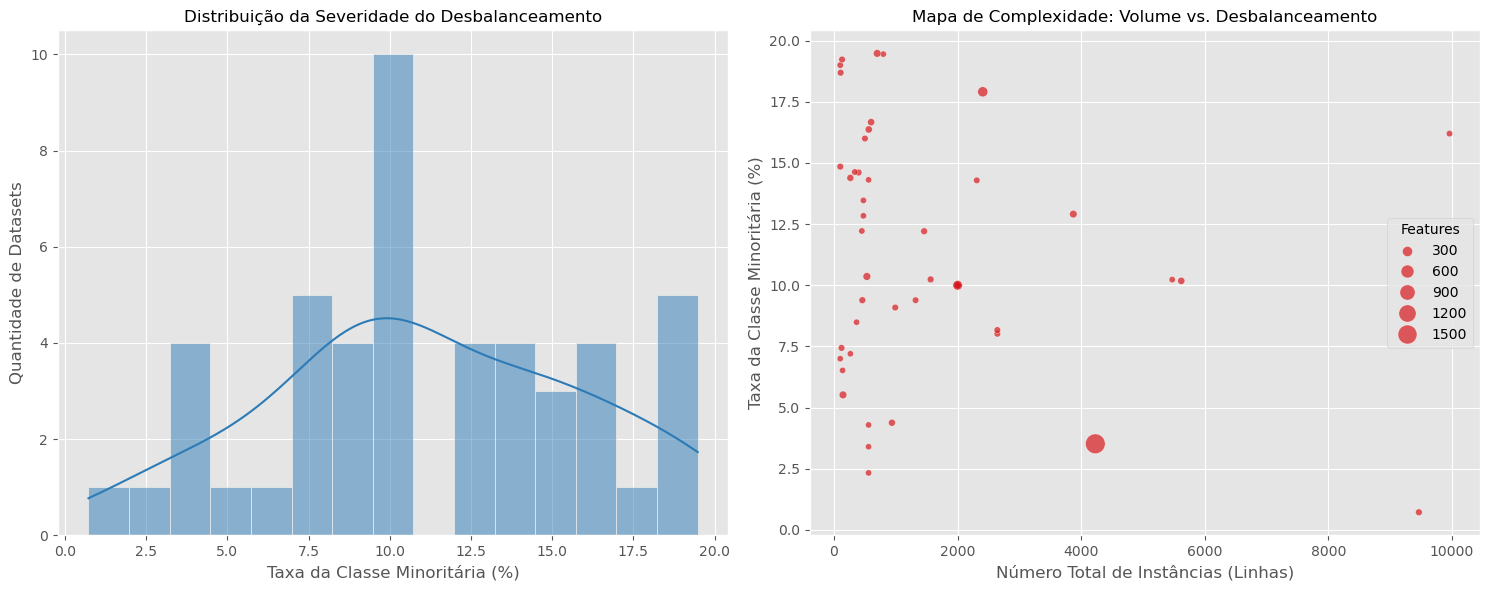

In [314]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Histograma
sns.histplot(data=df_resumo, x='Porcentagem classe minoritária', bins=15, kde=True, ax=ax[0], color='#2c7bb6')
ax[0].set_title('Distribuição da Severidade do Desbalanceamento', fontsize=12)
ax[0].set_xlabel('Taxa da Classe Minoritária (%)')
ax[0].set_ylabel('Quantidade de Datasets')

# Gráfico 2: Scatter Plot (Linhas vs Desbalanceamento)
sns.scatterplot(data=df_resumo, x='Linhas', y='Porcentagem classe minoritária', size='Features', 
                sizes=(20, 200), alpha=0.7, ax=ax[1], color='#d7191c')
ax[1].set_title('Mapa de Complexidade: Volume vs. Desbalanceamento', fontsize=12)
ax[1].set_xlabel('Número Total de Instâncias (Linhas)')
ax[1].set_ylabel('Taxa da Classe Minoritária (%)')

plt.tight_layout()
plt.show()

### 1.4.4) Treinando o modelo
&nbsp;Agora que já conhecemos os dados em que vamos trabalhar, e os mesmos estão padronizados, podemos iniciar a rotina de treino do modelo. Aqui, tomamos o cuidado de primeiro fazer o **split** dos datasets antes de aplicar a **Standardization** (Padronização Z-Score) para evitar **Data Leakege**. O Data Leakage ocorre quando informações do conjunto de teste (ou de validação) "vazam" de forma acidental para o conjunto de treino enquanto o modelo está sendo construído ou pré-processado.

#### 1.4.4.1) Split (Holdout):
&nbsp;Para a avaliação empírica do modelo de **Regressão Logística**, optou-se pela estratégia de Holdout Estratificado (80/20) como protocolo de divisão dos dados. Esta escolha justifica-se, primordialmente, pelo desafio imposto pelo desbalanceamento de classes (class imbalance) presente no repositório, a estratificação garante que a proporção original entre a classe majoritária e a minoritária seja rigorosamente preservada tanto no conjunto de treino quanto no de teste, mitigando o risco de sub-representação ou ausência da classe rara na etapa de validação. Adicionalmente, considerando o volume experimental massivo de 50 datasets distintos, o método Holdout apresenta uma eficiência computacional substancialmente superior quando comparado ao K-Fold Cross-Validation. Como o algoritmo de otimização por Gradiente Descendente foi desenvolvido de forma customizada (do zero), o Holdout reduz o custo de processamento ao exigir apenas uma única execução por conjunto de dados, viabilizando uma rotina de benchmarking altamente otimizada, escalável e matematicamente justa para todos os cenários testados.

In [316]:
def my_holdout_estradificado(X,y,test=0.2,random_state=1010):
    np.random.seed(random_state)

    class_0 = np.where(y == 0)[0]#indice
    class_1 = np.where(y == 1)[0]

    corte_0 = int(len(class_0)*test)#split index
    corte_1 = int(len(class_1)*test)

    teste_class_0 = class_0[:corte_0]#separa
    teste_class_1 = class_1[:corte_1]

    treino_class_0 = class_0[corte_0:]
    treino_class_1 = class_1[corte_1:]

    i_teste = np.concatenate([teste_class_0,teste_class_1])#junta
    i_treino = np.concatenate([treino_class_0,treino_class_1])

    np.random.shuffle(i_teste)#embaralha
    np.random.shuffle(i_treino)

    X_treino = X[i_treino]
    X_teste = X[i_teste]
    y_treino = y[i_treino]
    y_teste = y[i_teste]

    return X_treino, X_teste, y_treino, y_teste


In [322]:
X_treinos = []
X_testes = []
y_treinos = []
y_testes = []

for dataset in datasets_ref:
    df = pd.read_csv(dataset)
    X = df.drop('class', axis=1).values
    y = df['class'].values
    X_treino, X_teste, y_treino, y_teste = my_holdout_estradificado(X,y)
    X_treinos.append(X_treino)
    X_testes.append(X_teste)
    y_treinos.append(y_treino)
    y_testes.append(y_teste)

#### 1.4.4.2) Padronização (Standardization Z-Score):


In [327]:
def my_standardization(X_treino,X_teste):
    media = np.mean(X_treino,axis=0)
    desvio = np.std(X_treino, axis=0)

    desvio[desvio == 0] = 1.0 #evita /0

    X_treino_s = (X_treino-media)/desvio
    X_teste_s = (X_teste-media)/desvio

    return X_treino_s, X_teste_s

In [330]:
X_treinos = []
X_testes = []
y_treinos = []
y_testes = []

for dataset in datasets_ref:
    df = pd.read_csv(dataset)
    
    # Separa X e y em matrizes NumPy brutas
    X = df.drop('class', axis=1).values
    y = df['class'].values
    
    # Passo 1: Divide os dados mantendo a proporção das classes (Do zero!)
    X_treino, X_teste, y_treino, y_teste = my_holdout_estradificado(X, y)
    
    # Passo 2: Padroniza os dados usando a régua do treino (Do zero!)
    X_treino_scaled, X_teste_scaled = my_standardization(X_treino, X_teste)
    
    # Alimenta as suas 4 listas com os dados prontos para a Regressão Logística
    X_treinos.append(X_treino_scaled)
    X_testes.append(X_teste_scaled)
    y_treinos.append(y_treino)
    y_testes.append(y_teste)

print("Parabéns! Todos os 48 datasets foram divididos e padronizados sem nenhuma biblioteca externa!")

Parabéns! Todos os 48 datasets foram divididos e padronizados sem nenhuma biblioteca externa!


#### 1.4.4.3) Treino:

In [331]:
import my_lr

# Listas finais para guardar os parâmetros treinados de cada um dos 48 conjuntos
todos_os_pesos = []
todos_os_bias = []

# Loop direto pelo tamanho das suas 4 listas atuais
for i in range(len(X_treinos)):
    
    # Pega os dados direto das listas que você já preencheu
    X_train = X_treinos[i]
    y_train = y_treinos[i]
    
    # Treina usando o my_lr
    # O "_" serve para ignorar o histórico de custo que a sua função retorna
    pesos, bias, _ = my_lr.treinar_regressao_logistica(
        X_train, 
        y_train, 
        alpha=0.1, 
        epocas=1500, 
        tolerancia=1e-6
    )
    
    # Guarda os resultados nas posições correspondentes (0 até 47)
    todos_os_pesos.append(pesos)
    todos_os_bias.append(bias)

print(f"Treinamento concluído! {len(todos_os_pesos)} modelos foram treinados com sucesso.")

Treinamento concluído! 48 modelos foram treinados com sucesso.


#### 1.4.4.4) Teste:


In [335]:
def calcular_acuracia(y_real, y_pred):
    return np.mean(y_real == y_pred)

def calcular_sensibilidade(y_real, y_pred):
    # Focado na classe minoritária (0) como o nosso 'positivo'
    tp = np.sum((y_real == 0) & (y_pred == 0))
    fn = np.sum((y_real == 0) & (y_pred == 1))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def calcular_recall(y_real, y_pred):
    # Lógica idêntica à Sensibilidade (sinônimos na matriz de confusão)
    tp = np.sum((y_real == 0) & (y_pred == 0))
    fn = np.sum((y_real == 0) & (y_pred == 1))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def calcular_f1_score(y_real, y_pred):
    tp = np.sum((y_real == 0) & (y_pred == 0))
    fp = np.sum((y_real == 1) & (y_pred == 0))
    fn = np.sum((y_real == 0) & (y_pred == 1))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def calcular_auc(y_real, y_prob):
    # Ordena os dados reais baseando-se nas probabilidades previstas de forma decrescente
    indices_ordenados = np.argsort(y_prob)
    y_real_ord = y_real[indices_ordenados]
    
    n_pos = np.sum(y_real_ord == 0) # Classe alvo minoritária
    n_neg = np.sum(y_real_ord == 1)
    
    if n_pos == 0 or n_neg == 0:
        return 0.5
        
    tp, fp = 0, 0
    tpr_pts, fpr_pts = [0.0], [0.0]
    
    for label in y_real_ord:
        if label == 0:
            tp += 1
        else:
            fp += 1
        tpr_pts.append(tp / n_pos)
        fpr_pts.append(fp / n_neg)
        
    # Regra dos Trapézios para calcular a área sob a curva (AUC) do zero
    auc = 0.0
    for i in range(1, len(fpr_pts)):
        auc += (fpr_pts[i] - fpr_pts[i-1]) * (tpr_pts[i] + tpr_pts[i-1]) / 2.0
    return auc

In [336]:
import my_lr

# Listas para guardar as predições brutas de cada um dos 48 datasets
todas_as_probabilidades = []
todas_as_classes_preditas = []

for i in range(len(X_testes)):
    X_test = X_testes[i]
    pesos = todos_os_pesos[i]
    bias = todos_os_bias[i]
    
    # Executa os métodos do seu arquivo my_lr
    y_prob = my_lr.prever_probabilidade(X_test, pesos, bias)
    y_pred = my_lr.prever_classe(X_test, pesos, bias, limiar=0.5)
    
    # Guarda os arrays resultantes
    todas_as_probabilidades.append(y_prob)
    todas_as_classes_preditas.append(y_pred)

print(f"Previsões concluídas para os {len(todas_as_classes_preditas)} conjuntos de teste!")

Previsões concluídas para os 48 conjuntos de teste!


In [338]:
# Listas para acumular os valores individuais e computar as médias depois
lista_acc = []
lista_sens = []
lista_rec = []
lista_f1 = []
lista_auc = []

print("--- PERFORMANCE INDIVIDUAL DOS DATASETS ---")

for i in range(len(y_testes)):
    y_real = y_testes[i]
    y_pred = todas_as_classes_preditas[i]
    y_prob = todas_as_probabilidades[i]
    
    # Chama cada uma das funções criadas na Parte 1
    acc = calcular_acuracia(y_real, y_pred)
    sens = calcular_sensibilidade(y_real, y_pred)
    rec = calcular_recall(y_real, y_pred)
    f1 = calcular_f1_score(y_real, y_pred)
    auc_score = calcular_auc(y_real, y_prob)
    
    # Guarda nas listas globais
    lista_acc.append(acc)
    lista_sens.append(sens)
    lista_rec.append(rec)
    lista_f1.append(f1)
    lista_auc.append(auc_score)
    
    # Print individual formatado
    print(f"Dataset {i+1:02d} | Acc: {acc:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc_score:.4f}")

# Consolidação final tirando as médias
print("\n" + "=" * 55)
print("--- MÉDIA CONSOLIDADA FINAL (48 DATASETS COMBINADOS) ---")
print(f"Média Acurácia:      {np.mean(lista_acc):.4f}")
#print(f"Média Sensibilidade: {np.mean(lista_sens):.4f}")
print(f"Média Recall:        {np.mean(lista_rec):.4f}")
print(f"Média F1-Score:      {np.mean(lista_f1):.4f}")
print(f"Média AUC-ROC:       {np.mean(lista_auc):.4f}")
print("=" * 55)

--- PERFORMANCE INDIVIDUAL DOS DATASETS ---
Dataset 01 | Acc: 0.9732 | Rec: 0.8889 | F1: 0.9143 | AUC: 0.9965
Dataset 02 | Acc: 1.0000 | Rec: 1.0000 | F1: 1.0000 | AUC: 1.0000
Dataset 03 | Acc: 0.9747 | Rec: 0.7778 | F1: 0.8485 | AUC: 0.9963
Dataset 04 | Acc: 0.8500 | Rec: 0.0000 | F1: 0.0000 | AUC: 0.6471
Dataset 05 | Acc: 0.9931 | Rec: 0.0000 | F1: 0.0000 | AUC: 0.9278
Dataset 06 | Acc: 0.8421 | Rec: 1.0000 | F1: 0.6667 | AUC: 1.0000
Dataset 07 | Acc: 0.9583 | Rec: 0.5116 | F1: 0.6667 | AUC: 0.9521
Dataset 08 | Acc: 0.9950 | Rec: 1.0000 | F1: 0.9756 | AUC: 0.9997
Dataset 09 | Acc: 0.9808 | Rec: 1.0000 | F1: 0.8571 | AUC: 0.9864
Dataset 10 | Acc: 0.8654 | Rec: 0.5714 | F1: 0.5333 | AUC: 0.8698
Dataset 11 | Acc: 0.9975 | Rec: 0.9750 | F1: 0.9873 | AUC: 0.9846
Dataset 12 | Acc: 0.9400 | Rec: 0.7500 | F1: 0.8000 | AUC: 0.9688
Dataset 13 | Acc: 0.9679 | Rec: 0.2500 | F1: 0.4000 | AUC: 0.9288
Dataset 14 | Acc: 0.9506 | Rec: 0.6250 | F1: 0.6977 | AUC: 0.9676
Dataset 15 | Acc: 0.9910 | Rec: 